# Predicting When Machines Will Fail: Random Forest vs. LSTM

This notebook asks a simple question: **can a computer look at sensor readings from a machine and tell us how much longer it will keep working?**

In industry this is called **predictive maintenance**. Instead of repairing machines after they break (expensive and disruptive) or replacing parts on a fixed calendar (often wasteful), a company can repair each machine just before it is likely to fail. Think of a car that tells you "about 800 km until your brake pads need replacing", based on how you actually drive, rather than a sticker that says "change every 12 months".

The number we try to predict is the **Remaining Useful Life (RUL)**: how many more operating cycles a machine has before it fails.

We compare two well-known AI approaches:

- **Random Forest**, a classic machine learning model that combines the votes of hundreds of simple decision trees.
- **LSTM (Long Short-Term Memory)**, a type of neural network designed to read sequences of data over time.

This notebook supports the essay *Predictive Maintenance in Smart Manufacturing: Evaluating AI Models for Equipment Failure Prediction*, written for the MSc in Artificial Intelligence at Berlin School of Business and Innovation (BSBI).

**Contents**

- Step 0. Setup
- Step 1. Loading the data
- Step 2. Exploring the data
- Step 3. Preparing the data
- Step 4. Model 1: Random Forest
- Step 5. Model 2: LSTM
- Step 6. Results on the official test set
- Step 7. Explaining the predictions with SHAP
- Step 8. Summary and key findings

## How to run this notebook

1. Install the libraries listed in `requirements.txt` (for example with `pip install -r requirements.txt`).
2. Place the NASA CMAPSS text files (`train_FD001.txt`, `test_FD001.txt` and `RUL_FD001.txt`) anywhere inside the project folder. The notebook finds them automatically.
3. Run all cells from top to bottom. Training the LSTM with cross-validation takes around 15 to 30 minutes on a normal laptop without a GPU. To make it faster, set `LSTM_CV = False` in Step 0.

All charts are saved automatically in the `figures/` folder.

## Step 0. Setup

This cell loads the tools we need and sets the main parameters in one place, like the settings menu of an app. Changing a value here changes it for the whole notebook.

- `RUL_CAP = 125`: the highest RUL value we try to predict (explained in Step 3).
- `WINDOW = 30`: how many recent cycles the models look at for each prediction.
- `N_FOLDS = 5`: how many rounds of testing we use during cross-validation (explained in Step 4).
- `ALERT_RUL = 30`: if a machine is predicted to fail within 30 cycles, we raise a maintenance alert.

`SEED = 42` fixes the randomness so that the results can be reproduced.

In [1]:
import os, glob, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, precision_score, recall_score, f1_score
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)

SUBSET      = "FD001"   # CMAPSS subset
RUL_CAP     = 125       # RUL cap (piecewise linear target), standard practice in the literature
WINDOW      = 30        # cycles per window
N_FOLDS     = 5         # GroupKFold, grouped by engine
ALERT_RUL   = 30        # alert threshold: "will fail within 30 cycles"
LSTM_CV     = True      # set to False to skip LSTM cross-validation (faster)
LSTM_EPOCHS = 60

os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

## Step 1. Loading the data

We use the **NASA CMAPSS** dataset (Saxena et al., 2008), the most widely used benchmark for this type of problem. NASA created it with a detailed computer simulation of aircraft jet engines, recording each engine from the moment it is healthy until it fails.

We use the subset **FD001**, the simplest one: all engines work under the same conditions and fail for the same reason (wear in the high-pressure compressor).

The data comes in three files:

- **Training set:** 100 engines, each recorded from start to failure.
- **Test set:** 100 different engines, but the recording stops at some point before failure.
- **RUL file:** the true remaining life of each test engine, which we use to check the predictions.

Each row is one **operating cycle** (similar to one flight) and contains 3 operating settings and 21 sensor readings, such as temperatures, pressures and fan speeds. It is like a patient's medical record, where each row is one check-up with blood pressure, temperature and heart rate.

In [2]:
def find_file(name):
    """Search the project folder (and Kaggle's input folder) for a data file."""
    for base in ["/kaggle/input", "."]:
        for root, dirs, files in os.walk(base, followlinks=True):
            for f in files:
                if f.lower() == name.lower():
                    return os.path.join(root, f)
    raise FileNotFoundError(f"Could not find {name}. Please add the dataset to the project folder.")

COLS = ["unit", "cycle", "os1", "os2", "os3"] + [f"s{i}" for i in range(1, 22)]
read = lambda f: pd.read_csv(find_file(f), sep=r"\s+", header=None, names=COLS)

train = read(f"train_{SUBSET}.txt")
test  = read(f"test_{SUBSET}.txt")
rul_true = pd.read_csv(find_file(f"RUL_{SUBSET}.txt"), sep=r"\s+", header=None, names=["RUL"])

print("train:", train.shape, "| test:", test.shape, "| RUL test:", rul_true.shape)
print("Engines (train):", train.unit.nunique(), "| Engines (test):", test.unit.nunique())
train.head()

train: (20631, 26) | test: (13096, 26) | RUL test: (100, 1)
Engines (train): 100 | Engines (test): 100


,unit,cycle,os1,os2,os3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Step 2. Exploring the data

Before building any model, we look at the data to answer three questions:

1. **How long do engines live?** If every engine failed after exactly 200 cycles, we would not need AI: a calendar would be enough.
2. **Are all sensors useful?** A thermometer that always shows the same number tells us nothing.
3. **Do the sensors change as an engine gets closer to failure?** If they do, there is a pattern the models can learn.

count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0
Name: cycle, dtype: float64
Missing values: 0


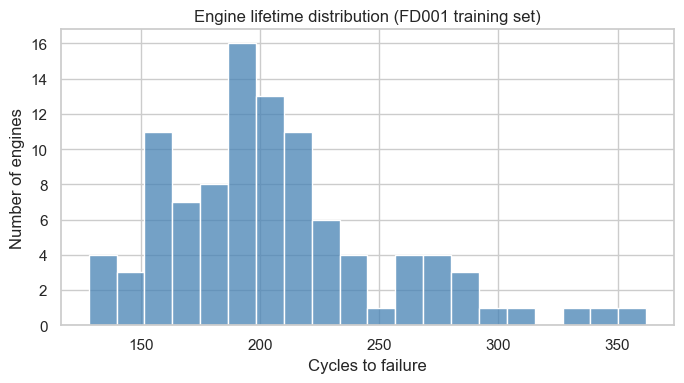

In [3]:
life = train.groupby("unit").cycle.max()
print(life.describe().round(1))
print("Missing values:", train.isna().sum().sum())

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(life, bins=20, ax=ax, color="steelblue")
ax.set(title=f"Engine lifetime distribution ({SUBSET} training set)", xlabel="Cycles to failure", ylabel="Number of engines")
plt.tight_layout(); plt.savefig("figures/fig_lifetime_distribution.png", dpi=200); plt.show()

Engine lifetimes vary a lot, from 128 to 362 cycles. This is exactly why a fixed maintenance schedule does not work well: some engines would be repaired too early and others too late. The dataset also has no missing values.

In [4]:
std = train.drop(columns=["unit", "cycle"]).std().sort_values()
print("Standard deviation per variable (values close to zero carry no information):")
print(std.round(5).to_string())

Standard deviation per variable (values close to zero carry no information):
os3     0.00000
s19     0.00000
s18     0.00000
s16     0.00000
s10     0.00000
s5      0.00000
s1      0.00000
os2     0.00029
s6      0.00139
os1     0.00219
s15     0.03751
s8      0.07099
s13     0.07192
s21     0.10825
s20     0.18075
s11     0.26709
s2      0.50005
s12     0.73755
s7      0.88509
s17     1.54876
s3      6.13115
s4      9.00060
s14    19.07618
s9     22.08288


The **standard deviation** measures how much a value moves. Several variables at the top of the list barely move at all, so they cannot help us. We remove them in Step 3.

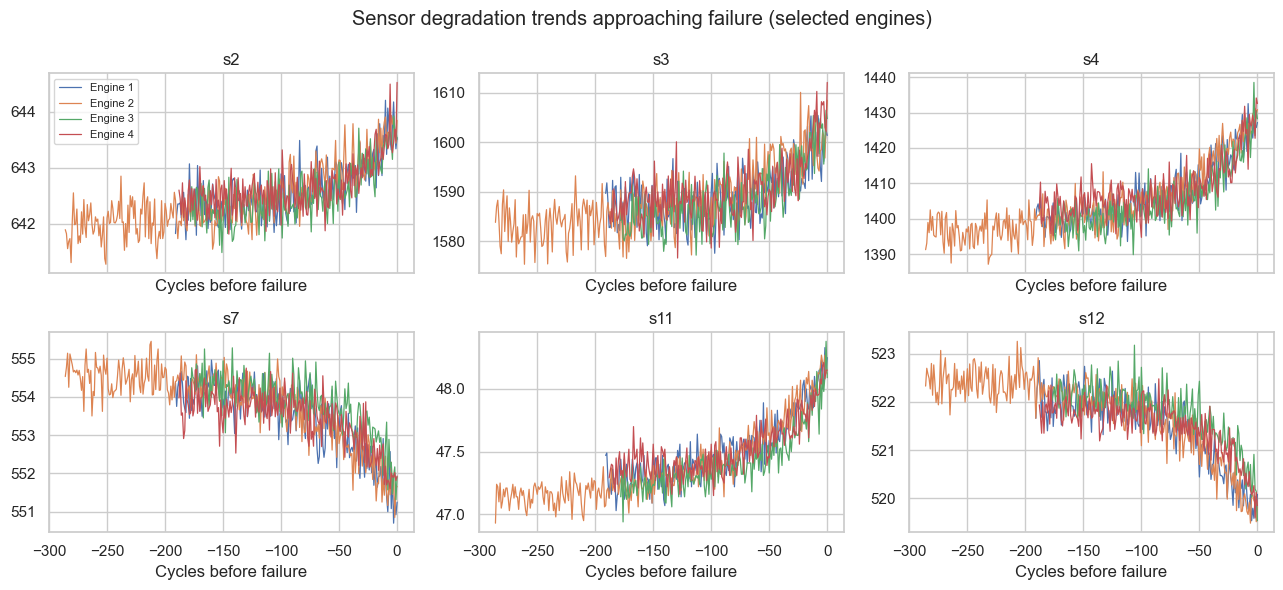

In [5]:
# Trends of selected sensors in 4 engines, aligned by cycles before failure
plot_sensors = ["s2", "s3", "s4", "s7", "s11", "s12"]
units = train.unit.unique()[:4]
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
for ax, s in zip(axes.ravel(), plot_sensors):
    for u in units:
        d = train[train.unit == u]
        ax.plot(d.cycle - d.cycle.max(), d[s], lw=0.9, label=f"Engine {u}")
    ax.set_title(s); ax.set_xlabel("Cycles before failure")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Sensor degradation trends approaching failure (selected engines)")
plt.tight_layout(); plt.savefig("figures/fig_sensor_trends.png", dpi=200); plt.show()

Each line is one engine, and the horizontal axis counts down to failure (0 = the moment the engine fails). Most sensors stay fairly flat at first and then rise or fall as failure gets closer, similar to how a fever builds up before an illness becomes serious. This gradual pattern is what our models will try to learn.

## Step 3. Preparing the data

Raw data is rarely ready for a model. This step is like preparing ingredients before cooking:

1. **Creating the target (RUL).** For each row in the training set we calculate how many cycles remain until that engine fails.
2. **Capping the RUL at 125 cycles.** When an engine is new, its sensors look the same whether it has 300 or 200 cycles left, just like a brand-new tyre looks the same whether it will last 50,000 or 60,000 km. Asking the model to tell these cases apart would be unfair, so any RUL above 125 is set to 125. This is common practice in the research literature.
3. **Removing useless variables.** Sensors and settings that hardly change are removed, which leaves 14 sensors.
4. **Scaling.** Sensors use very different units (a temperature around 640, a pressure around 8). We rescale them all to a range between 0 and 1, like converting exam marks out of 10 and out of 100 to percentages so they can be compared. The scaling is learned from the training data only, so no information from the test set leaks into the model.
5. **Windows of 30 cycles.** Instead of looking at a single moment, the models look at the last 30 cycles of each engine. A single photo of someone running tells you little; a short video shows whether they are speeding up or getting tired.

Removed: ['os1', 'os2', 'os3', 's1', 's5', 's6', 's10', 's16', 's18', 's19']
Sensors used (14): ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


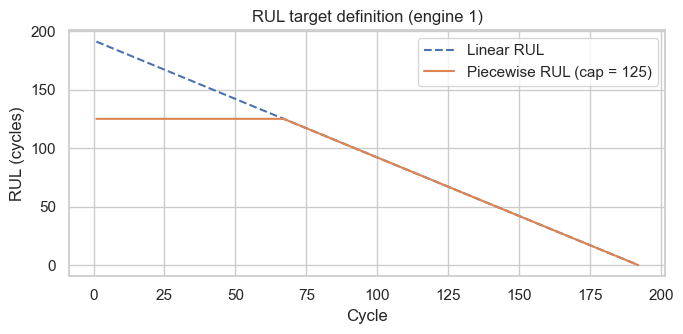

In [6]:
train["RUL"] = train.groupby("unit").cycle.transform("max") - train.cycle
train["RUL"] = train["RUL"].clip(upper=RUL_CAP)

drop_cols = [c for c in COLS[2:] if train[c].std() < 0.01]   # includes the 3 operating settings: FD001 has a single operating condition
SENSORS = [c for c in COLS[2:] if c not in drop_cols]
print("Removed:", drop_cols)
print(f"Sensors used ({len(SENSORS)}):", SENSORS)

fig, ax = plt.subplots(figsize=(7, 3.5))
d = train[train.unit == 1]
ax.plot(d.cycle, d.cycle.max() - d.cycle, "--", label="Linear RUL")
ax.plot(d.cycle, d.RUL, label=f"Piecewise RUL (cap = {RUL_CAP})")
ax.set(title="RUL target definition (engine 1)", xlabel="Cycle", ylabel="RUL (cycles)"); ax.legend()
plt.tight_layout(); plt.savefig("figures/fig_rul_target.png", dpi=200); plt.show()

The chart shows the difference between a simple countdown (dashed line) and the capped target we use (solid line): it stays flat at 125 while the engine is healthy and only starts counting down once wear becomes visible.

The next cell builds the 30-cycle windows. For the **Random Forest**, each window is summarised into four simple numbers per sensor: its latest value, its average, how much it varies, and its trend (going up or down). This gives 56 features in total. The **LSTM** receives the full 30-cycle sequence instead.

In [7]:
def make_windows(df, scaler, last_only=False):
    """Return X (n, WINDOW, sensors), the target y and the engine id of each window."""
    X, y, g = [], [], []
    for u, d in df.groupby("unit"):
        a = scaler.transform(d[SENSORS])
        if len(a) < WINDOW:                      # padding for very short test engines
            a = np.vstack([np.repeat(a[:1], WINDOW - len(a), axis=0), a])
        starts = [len(a) - WINDOW] if last_only else range(len(a) - WINDOW + 1)
        for s in starts:
            X.append(a[s:s + WINDOW]); g.append(u)
            if "RUL" in d: y.append(d.RUL.values[min(s + WINDOW, len(d)) - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(g)

def window_features(X):
    """Summary features per sensor for the Random Forest: last value, mean, standard deviation and slope."""
    t = np.arange(X.shape[1]); t = (t - t.mean()) / ((t - t.mean()) ** 2).sum()
    slope = np.einsum("t,nts->ns", t, X)
    return np.hstack([X[:, -1, :], X.mean(1), X.std(1), slope])

FEAT_NAMES = [f"{s}_{k}" for k in ["last", "mean", "std", "slope"] for s in SENSORS]

scaler = MinMaxScaler().fit(train[SENSORS])
X_tr, y_tr, g_tr = make_windows(train, scaler)
X_te, _, g_te    = make_windows(test, scaler, last_only=True)
y_te = rul_true.RUL.values.astype(np.float32)
y_te_capped = np.minimum(y_te, RUL_CAP)

print("Training windows:", X_tr.shape, "| test windows:", X_te.shape)
print("Random Forest features:", len(FEAT_NAMES))

Training windows: (17731, 30, 14) | test windows: (100, 30, 14)
Random Forest features: 56


### How we measure success

We use several measures, because each one answers a different question:

- **RMSE (Root Mean Squared Error):** on average, by how many cycles does the prediction miss? Large mistakes count extra. Lower is better.
- **MAE (Mean Absolute Error):** the plain average miss in cycles. Lower is better.
- **NASA score:** a measure designed for this dataset that punishes **late** predictions much more than early ones. Arriving at the airport two hours early is annoying; arriving ten minutes late means you miss the flight. In maintenance, a late prediction can mean a breakdown. Lower is better.
- **Precision and recall for the maintenance alert:** think of a smoke alarm. **Recall** asks "did the alarm go off for every real fire?" and **precision** asks "when the alarm went off, was there really a fire?" Here, a "fire" is an engine that will fail within 30 cycles.

In [8]:
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

def evaluate(y_true, y_pred):
    a_true, a_pred = y_true <= ALERT_RUL, y_pred <= ALERT_RUL
    return {"RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE": mean_absolute_error(y_true, y_pred),
            "NASA score": nasa_score(y_true, y_pred),
            "Precision": precision_score(a_true, a_pred, zero_division=0),
            "Recall": recall_score(a_true, a_pred, zero_division=0),
            "F1": f1_score(a_true, a_pred, zero_division=0)}

gkf = GroupKFold(n_splits=N_FOLDS)

## Step 4. Model 1: Random Forest

A **Random Forest** is a group of decision trees. Each tree is like a simple flowchart of yes/no questions ("Is the temperature trend rising faster than X?"). One tree alone makes many mistakes, but when 200 trees each give their answer and we take the average, the result is much more reliable, in the same way that the average guess of a large crowd is often surprisingly accurate.

**Cross-validation by engine.** To check the model fairly, we split the 100 training engines into 5 groups. The model learns from 4 groups and is tested on the 5th, and we repeat this 5 times so that every group is tested once. The engines used for testing are never seen during learning, just as a good teacher does not use the exam questions as homework.

In [9]:
F_tr, F_te = window_features(X_tr), window_features(X_te)
rf_params = dict(n_estimators=200, max_depth=15, min_samples_leaf=5, max_features=0.5, n_jobs=-1, random_state=SEED)

cv_rf = []
for k, (i_tr, i_va) in enumerate(gkf.split(F_tr, y_tr, g_tr), 1):
    m = RandomForestRegressor(**rf_params).fit(F_tr[i_tr], y_tr[i_tr])
    rmse = np.sqrt(mean_squared_error(y_tr[i_va], m.predict(F_tr[i_va])))
    cv_rf.append(rmse); print(f"Fold {k}: RMSE = {rmse:.2f}")
print(f"RF CV RMSE: {np.mean(cv_rf):.2f} ± {np.std(cv_rf):.2f}")

t0 = time.time(); rf = RandomForestRegressor(**rf_params).fit(F_tr, y_tr); rf_train_time = time.time() - t0
t0 = time.time(); pred_rf = rf.predict(F_te); rf_inf_ms = (time.time() - t0) / len(F_te) * 1000
print(f"Training time: {rf_train_time:.1f} s | prediction time: {rf_inf_ms:.3f} ms per engine")

Fold 1: RMSE = 14.48
Fold 2: RMSE = 13.71
Fold 3: RMSE = 13.11
Fold 4: RMSE = 12.39
Fold 5: RMSE = 12.93
RF CV RMSE: 13.32 ± 0.72
Training time: 23.0 s | prediction time: 1.035 ms per engine


## Step 5. Model 2: LSTM

An **LSTM** is a neural network designed for sequences. It reads the 30 cycles one by one, keeping a kind of short-term memory of what it has seen, a bit like reading a story sentence by sentence while remembering the earlier chapters. This lets it learn patterns over time directly from the raw sensor values, without us summarising them first.

Two details help the LSTM learn well:

- **Validation engines:** 20% of the training engines are kept aside to check progress during training.
- **Early stopping:** training stops when results on the validation engines stop improving, like a student who stops revising once practice-test scores no longer go up, to avoid simply memorising the answers.

Note: on Windows, TensorFlow uses the computer's processor (CPU) only, so this step is slower than the Random Forest.

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
tf.random.set_seed(SEED)
print("GPU:", tf.config.list_physical_devices("GPU"))

def build_lstm(n_features):
    m = models.Sequential([
        layers.Input(shape=(WINDOW, n_features)),
        layers.LSTM(64, return_sequences=True), layers.Dropout(0.2),
        layers.LSTM(32), layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return m

def fit_lstm(X, y, groups):
    i_tr, i_va = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED).split(X, y, groups))
    m = build_lstm(X.shape[2])
    es = callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    h = m.fit(X[i_tr], y[i_tr] / RUL_CAP, validation_data=(X[i_va], y[i_va] / RUL_CAP),
              epochs=LSTM_EPOCHS, batch_size=256, callbacks=[es], verbose=0)
    return m, h

predict_lstm = lambda m, X: m.predict(X, verbose=0).ravel() * RUL_CAP

GPU: []


Fold 1: RMSE = 17.12
Fold 2: RMSE = 13.73
Fold 3: RMSE = 14.56
Fold 4: RMSE = 13.61
Fold 5: RMSE = 15.00
LSTM CV RMSE: 14.80 ± 1.27
Training time: 175.3 s (38 epochs) | prediction time: 9.658 ms per engine


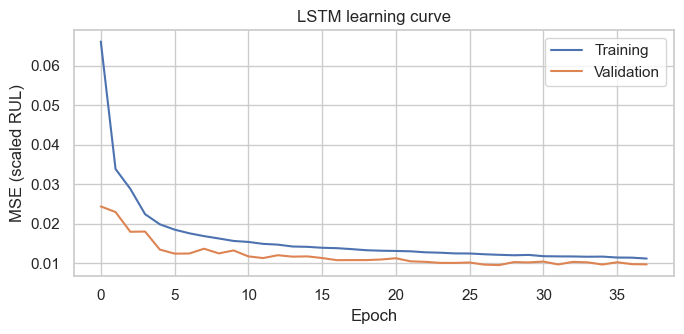

In [11]:
cv_lstm = []
if LSTM_CV:
    for k, (i_tr, i_va) in enumerate(gkf.split(X_tr, y_tr, g_tr), 1):
        m, _ = fit_lstm(X_tr[i_tr], y_tr[i_tr], g_tr[i_tr])
        rmse = np.sqrt(mean_squared_error(y_tr[i_va], predict_lstm(m, X_tr[i_va])))
        cv_lstm.append(rmse); print(f"Fold {k}: RMSE = {rmse:.2f}")
    print(f"LSTM CV RMSE: {np.mean(cv_lstm):.2f} ± {np.std(cv_lstm):.2f}")

t0 = time.time(); lstm, hist = fit_lstm(X_tr, y_tr, g_tr); lstm_train_time = time.time() - t0
t0 = time.time(); pred_lstm = predict_lstm(lstm, X_te); lstm_inf_ms = (time.time() - t0) / len(X_te) * 1000
print(f"Training time: {lstm_train_time:.1f} s ({len(hist.history['loss'])} epochs) | prediction time: {lstm_inf_ms:.3f} ms per engine")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(hist.history["loss"], label="Training"); ax.plot(hist.history["val_loss"], label="Validation")
ax.set(title="LSTM learning curve", xlabel="Epoch", ylabel="MSE (scaled RUL)"); ax.legend()
plt.tight_layout(); plt.savefig("figures/fig_lstm_learning_curve.png", dpi=200); plt.show()

The learning curve shows the error on the training engines and on the validation engines after each round (epoch) of training. Both lines go down and then level off, which means the model learned useful patterns without simply memorising the training data.

## Step 6. Results on the official test set

Now we test both models on the 100 test engines they have never seen. For each engine we use only its last 30 recorded cycles and compare the predicted RUL with the true value from NASA.

In the table, **RMSE (uncapped truth)** compares the predictions with the true RUL without the 125-cycle cap, which is a stricter check.

In [12]:
rows = []
for name, p, cv, tt, inf in [("Random Forest", pred_rf, cv_rf, rf_train_time, rf_inf_ms),
                             ("LSTM", pred_lstm, cv_lstm, lstm_train_time, lstm_inf_ms)]:
    r = {"Model": name, "CV RMSE (mean ± sd)": f"{np.mean(cv):.2f} ± {np.std(cv):.2f}" if cv else "n/a"}
    r.update({k: round(v, 3) for k, v in evaluate(y_te_capped, p).items()})
    r["RMSE (uncapped truth)"] = round(np.sqrt(mean_squared_error(y_te, p)), 2)
    r["Train time (s)"] = round(tt, 1); r["Inference (ms/engine)"] = round(inf, 3)
    rows.append(r)
results = pd.DataFrame(rows).set_index("Model")
results.to_csv("figures/table_results.csv")
results.T

Model,Random Forest,LSTM
CV RMSE (mean ± sd),13.32 ± 0.72,14.80 ± 1.27
RMSE,11.707,13.592
MAE,8.605,10.589
NASA score,210.757,314.769
Precision,0.95,1.0
Recall,0.76,0.8
F1,0.844,0.889
RMSE (uncapped truth),13.03,15.04
Train time (s),23.0,175.3
Inference (ms/engine),1.035,9.658


**Predicted vs. true RUL.** In the next chart, each dot is one test engine. A perfect model would place every dot on the dashed diagonal line. Dots above the line are **late** predictions (the model thinks the engine has more life left than it really has), which are the risky ones.

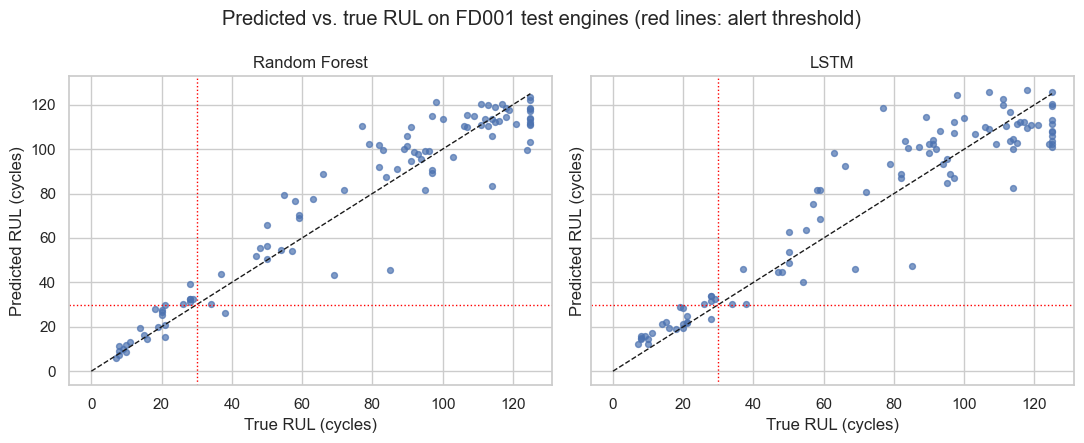

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (name, p) in zip(axes, [("Random Forest", pred_rf), ("LSTM", pred_lstm)]):
    ax.scatter(y_te_capped, p, s=18, alpha=0.7)
    ax.plot([0, RUL_CAP], [0, RUL_CAP], "k--", lw=1)
    ax.axvline(ALERT_RUL, color="red", ls=":", lw=1); ax.axhline(ALERT_RUL, color="red", ls=":", lw=1)
    ax.set(title=name, xlabel="True RUL (cycles)", ylabel="Predicted RUL (cycles)")
fig.suptitle(f"Predicted vs. true RUL on {SUBSET} test engines (red lines: alert threshold)")
plt.tight_layout(); plt.savefig("figures/fig_pred_vs_true.png", dpi=200); plt.show()

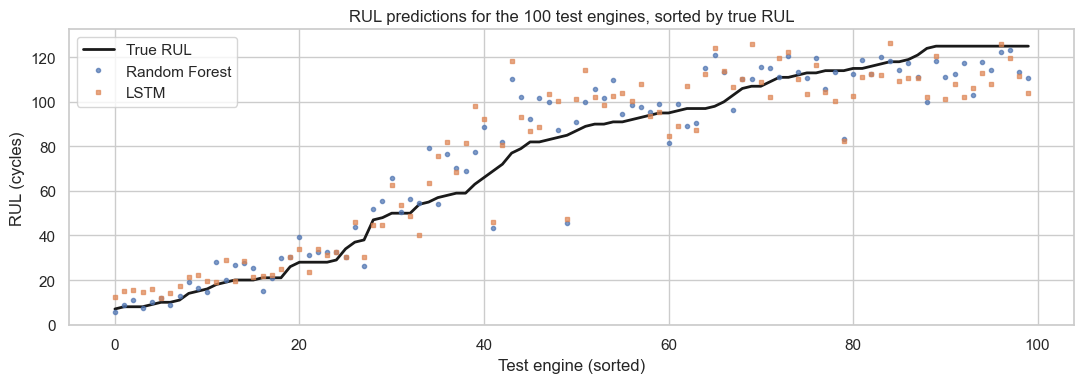

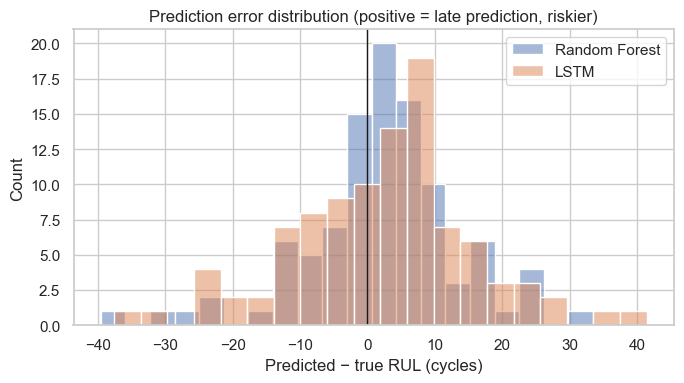

In [14]:
order = np.argsort(y_te_capped)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(y_te_capped[order], "k", lw=2, label="True RUL")
ax.plot(pred_rf[order], "o", ms=3, alpha=0.7, label="Random Forest")
ax.plot(pred_lstm[order], "s", ms=3, alpha=0.7, label="LSTM")
ax.set(title="RUL predictions for the 100 test engines, sorted by true RUL", xlabel="Test engine (sorted)", ylabel="RUL (cycles)")
ax.legend(); plt.tight_layout(); plt.savefig("figures/fig_sorted_predictions.png", dpi=200); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(pred_rf - y_te_capped, bins=20, alpha=0.5, label="Random Forest", ax=ax)
sns.histplot(pred_lstm - y_te_capped, bins=20, alpha=0.5, label="LSTM", ax=ax)
ax.axvline(0, color="k", lw=1)
ax.set(title="Prediction error distribution (positive = late prediction, riskier)", xlabel="Predicted − true RUL (cycles)")
ax.legend(); plt.tight_layout(); plt.savefig("figures/fig_error_distribution.png", dpi=200); plt.show()

**Maintenance alerts.** The confusion matrix counts how often each model raised the alert correctly. The bottom-left box is the most important one: engines that were about to fail but received **no alert** (false negatives). The top-right box shows false alarms.

Random Forest: FN = 6 | FP = 1 | late predictions = 64% | average late error = 8.4 cycles
LSTM: FN = 5 | FP = 0 | late predictions = 62% | average late error = 10.2 cycles


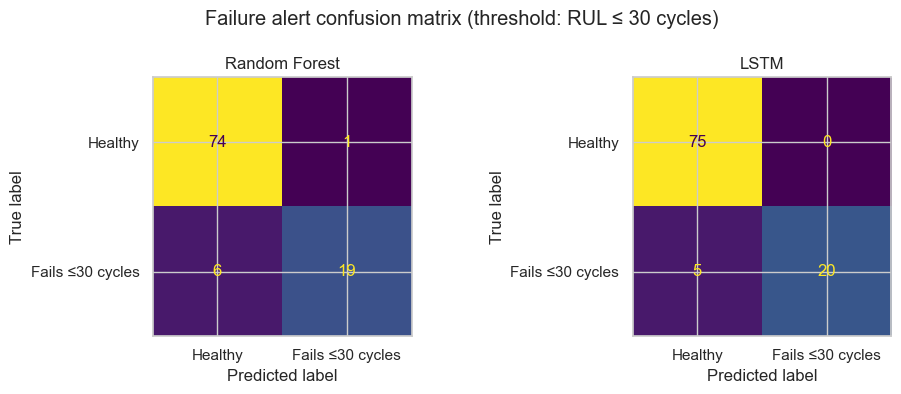

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, p) in zip(axes, [("Random Forest", pred_rf), ("LSTM", pred_lstm)]):
    cm = confusion_matrix(y_te_capped <= ALERT_RUL, p <= ALERT_RUL)
    ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Fails ≤30 cycles"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
    late = (p - y_te_capped) > 0
    print(f"{name}: FN = {cm[1,0]} | FP = {cm[0,1]} | "
          f"late predictions = {late.mean():.0%} | average late error = {(p - y_te_capped)[late].mean():.1f} cycles")
fig.suptitle(f"Failure alert confusion matrix (threshold: RUL ≤ {ALERT_RUL} cycles)")
plt.tight_layout(); plt.savefig("figures/fig_confusion_matrix.png", dpi=200); plt.show()

## Step 7. Explaining the predictions with SHAP

A prediction is only useful in a factory if engineers trust it. **SHAP** explains how much each input pushed a prediction up or down, like an itemised receipt that shows what each product added to the total bill.

We use SHAP on the Random Forest because it can calculate exact explanations for tree-based models quickly. Explaining an LSTM is harder and only gives approximate answers.

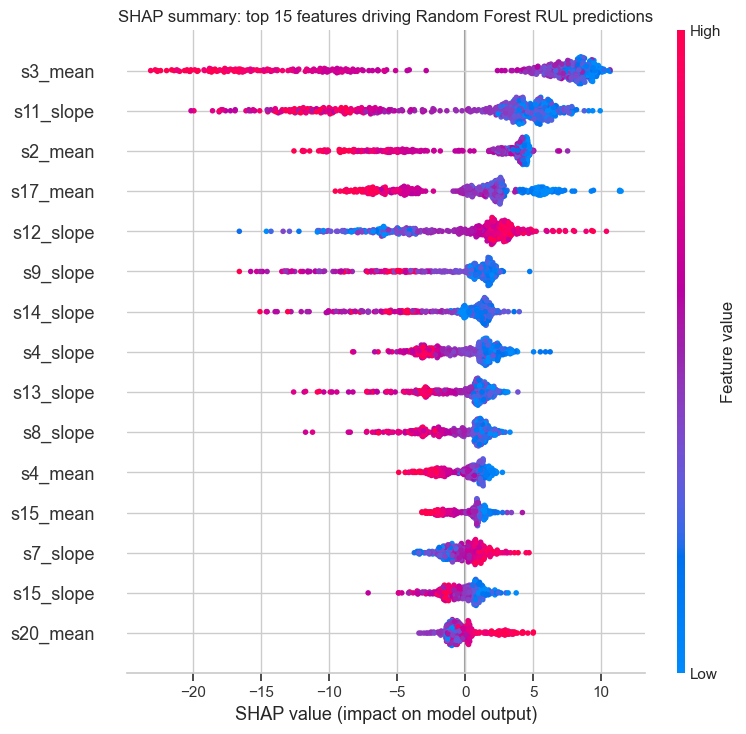

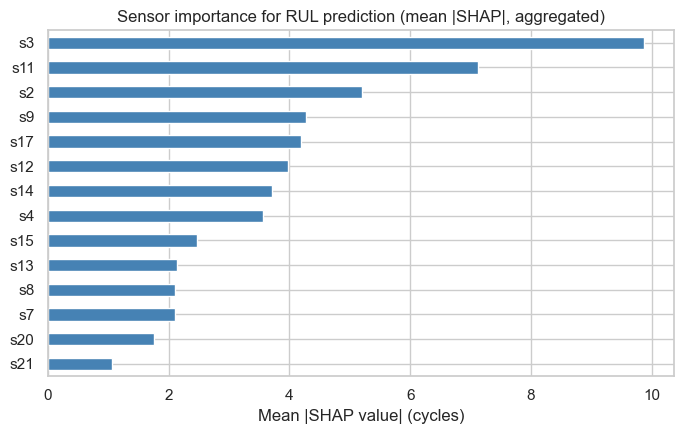

In [16]:
import shap
idx = np.random.RandomState(SEED).choice(len(F_tr), 500, replace=False)
explainer = shap.TreeExplainer(rf)
sv = explainer.shap_values(F_tr[idx])

shap.summary_plot(sv, F_tr[idx], feature_names=FEAT_NAMES, max_display=15, show=False)
plt.title("SHAP summary: top 15 features driving Random Forest RUL predictions")
plt.tight_layout(); plt.savefig("figures/fig_shap_summary.png", dpi=200, bbox_inches="tight"); plt.show()

# Importance per sensor (sum of the mean |SHAP| of its 4 features)
imp = pd.Series(np.abs(sv).mean(0), index=FEAT_NAMES)
by_sensor = imp.groupby(lambda f: f.split("_")[0]).sum().sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
by_sensor.plot.barh(ax=ax, color="steelblue")
ax.set(title="Sensor importance for RUL prediction (mean |SHAP|, aggregated)", xlabel="Mean |SHAP value| (cycles)")
plt.tight_layout(); plt.savefig("figures/fig_shap_by_sensor.png", dpi=200); plt.show()

The most important sensors are **s3** (temperature at the high-pressure compressor outlet), **s11** (static pressure at the high-pressure compressor outlet) and **s2** (temperature at the low-pressure compressor outlet, just before the high-pressure compressor). This makes physical sense: in FD001, engines fail because the high-pressure compressor wears out, and a worn compressor runs hotter and delivers different pressures. The model is relying on real signs of wear, not on random coincidences.

## Step 8. Summary

In [17]:
print(results.T.to_string())
print("\nSaved figures:")
for f in sorted(os.listdir("figures")): print(" -", f)

Model                 Random Forest          LSTM
CV RMSE (mean ± sd)    13.32 ± 0.72  14.80 ± 1.27
RMSE                         11.707        13.592
MAE                           8.605        10.589
NASA score                  210.757       314.769
Precision                      0.95           1.0
Recall                         0.76           0.8
F1                            0.844         0.889
RMSE (uncapped truth)         13.03         15.04
Train time (s)                 23.0         175.3
Inference (ms/engine)         1.035         9.658

Saved figures:
 - fig_confusion_matrix.png
 - fig_error_distribution.png
 - fig_lifetime_distribution.png
 - fig_lstm_learning_curve.png
 - fig_pred_vs_true.png
 - fig_rul_target.png
 - fig_sensor_trends.png
 - fig_shap_by_sensor.png
 - fig_shap_summary.png
 - fig_sorted_predictions.png
 - table_results.csv


### Key findings

- **The Random Forest estimated remaining life more accurately.** It had lower errors in cross-validation (RMSE 13.32 vs. 14.80) and on the official test set (RMSE 11.71 vs. 13.59, MAE 8.61 vs. 10.59), and a much better NASA score (211 vs. 315), meaning fewer costly late predictions.
- **The LSTM raised slightly better alerts.** It detected 20 of the 25 engines close to failure, against 19 for the Random Forest, with no false alarms. With only 25 such engines, a difference of one engine is too small to be conclusive.
- **Both models were often late.** Around 60% of predictions overestimated the remaining life, and both missed 5 or 6 engines close to failure. In a real factory, a safety margin (for example, raising the alert at 40 cycles instead of 30) would be needed.
- **The Random Forest was cheaper and easier to explain.** It trained about 8 times faster (23 s vs. 175 s) and predicted about 9 times faster, and SHAP showed that it relies on physically meaningful compressor sensors.

### Limitations

- CMAPSS is **simulated** data from aircraft engines, so the results need to be confirmed with real sensor data from the company's pumps, motors and conveyors.
- FD001 is the simplest subset (one operating condition, one type of failure). The LSTM's ability to learn patterns without hand-made features may be more valuable in more complex settings, such as the FD002 and FD004 subsets.
- The LSTM used a basic architecture without extensive tuning, so its results could probably be improved.

### Reference

Saxena, A., Goebel, K., Simon, D. and Eklund, N. (2008) 'Damage propagation modeling for aircraft engine run-to-failure simulation', *2008 International Conference on Prognostics and Health Management*. Denver, CO, USA: IEEE, pp. 1-9.